In [1]:
!pip install rioxarray geopandas cartopy pymannkendall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.7 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import xarray as xr
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
import numpy as np
from scipy.stats import linregress

Resolution Check

In [3]:
ro_raw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Runoff/Runoff.nc")
print(ro_raw)

lat = ro_raw["latitude"].values
lon = ro_raw["longitude"].values

lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])


print("Lat resolution ~", lat_res, "degrees")
print("Lon resolution ~", lon_res, "degrees at equator")

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 300, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2000-01-01T06:00:00 ... 2024-...
    expver      (valid_time) <U4 5kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
Data variables:
    ro          (valid_time, latitude, longitude) float32 1GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-25T15:39 GRIB to CDM+CF via cfgrib-0.9.1...
Lat resolution ~ 0.25 degrees
Lon resolution ~ 0.25 degrees at equator


Nearest Neighbor Interpolation to 0.25 degree cell

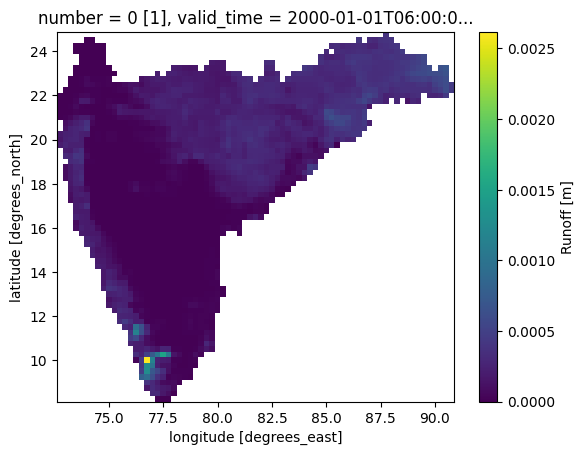

In [6]:
# Assign CRS and spatial dimensions
ro_raw = ro_raw.rio.write_crs("EPSG:4326")
ro_raw = ro_raw.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

# Read shapefile
gdf = gpd.read_file("/content/drive/MyDrive/GNR644 - Water Balance/Data/PeninsularIndia/peninsularIndia_lvl3.shp")
gdf = gdf.to_crs("EPSG:4326")

# Clip directly (NO resetting of spatial dims here)
ro_025 = ro_raw["ro"].rio.clip(gdf.geometry, gdf.crs, drop=True)

# Plot first timestep
ro_025.isel(valid_time=0).plot()

# Save
#ro_025.to_netcdf("/content/drive/MyDrive/GNR644 - Water Balance/Data/Runoff/Runoff_cropped.nc")


Monthly Mean Analysis

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


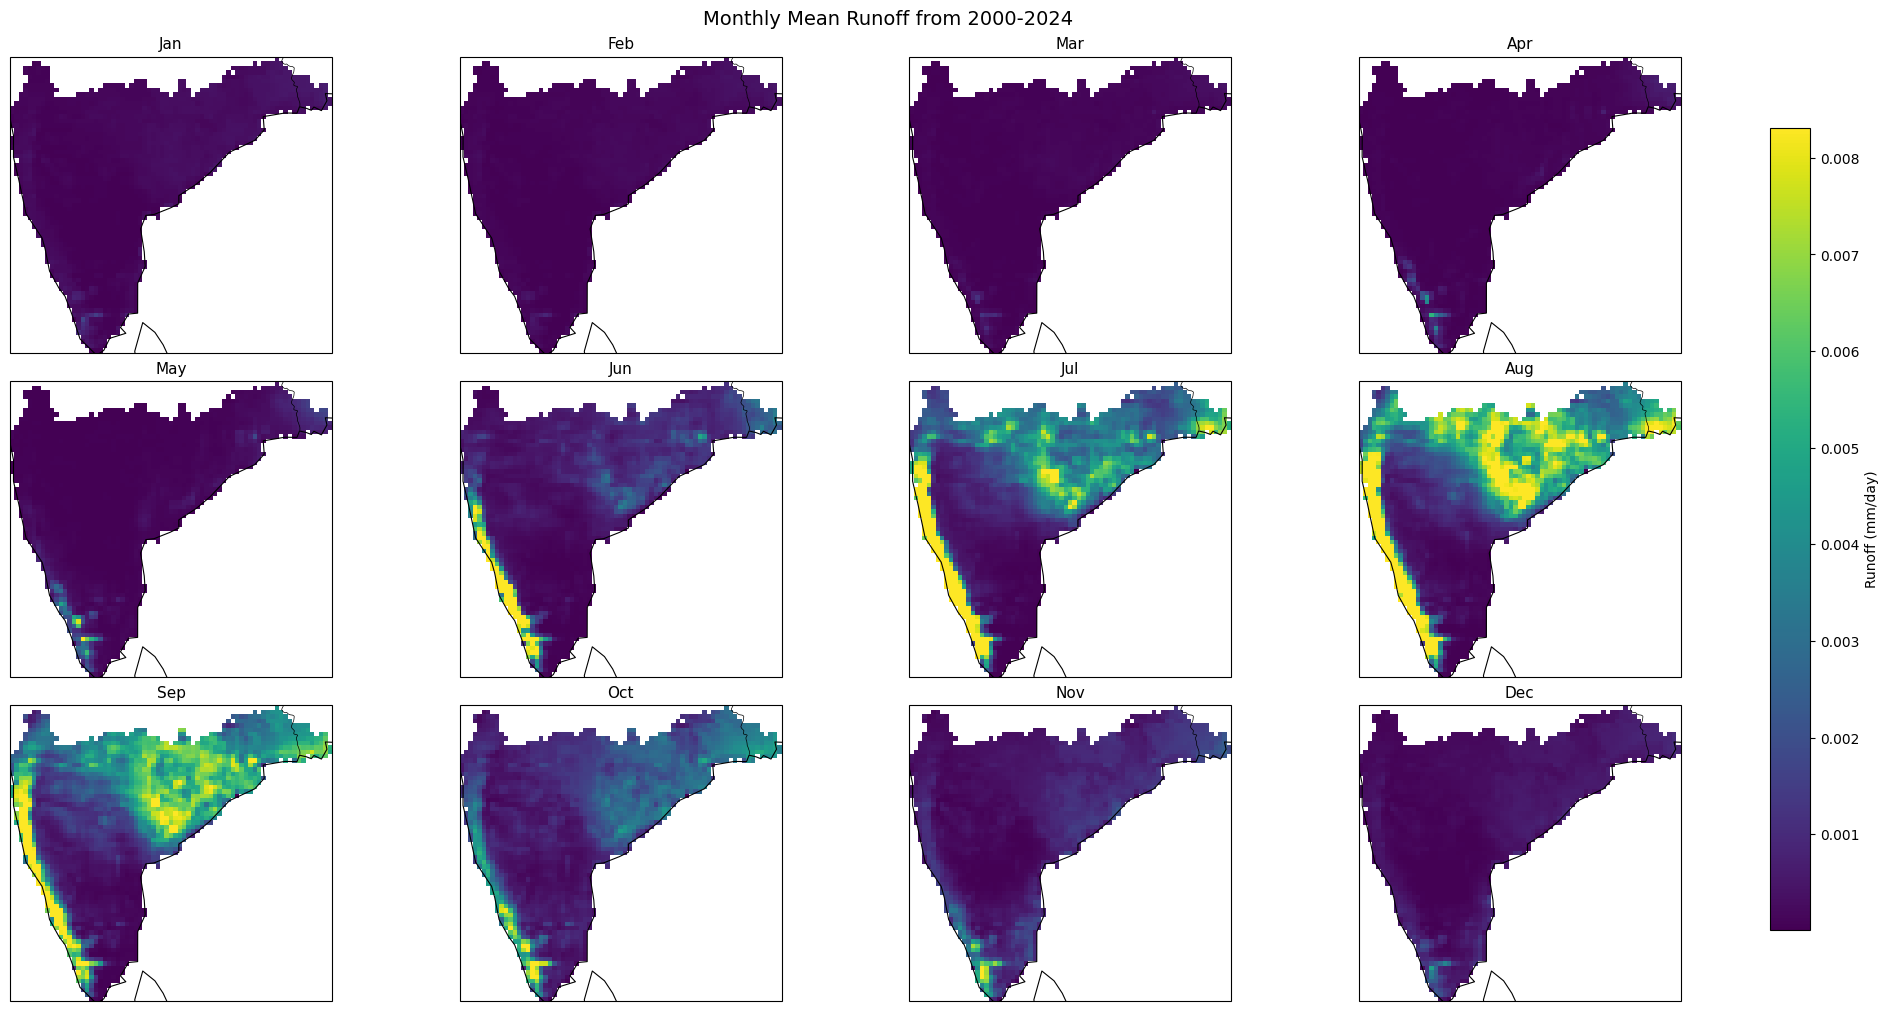

In [8]:
ro_025 = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Runoff/Runoff_cropped.nc")
ro = ro_025["ro"]

monthly_mean = ro.groupby("valid_time.month").mean(dim="valid_time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Runoff (mm/day)")

plt.suptitle(
    "Monthly Mean Runoff from 2000-2024",
    fontsize=14
)

plt.show()

Monthly Mann Kendall Trend Analysis

In [9]:
# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
results = {}

for month in range(1, 13):

    # Select month using correct time dimension
    ro_m = ro.sel(valid_time=ro["valid_time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        ro_m,
        input_core_dims=[["valid_time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


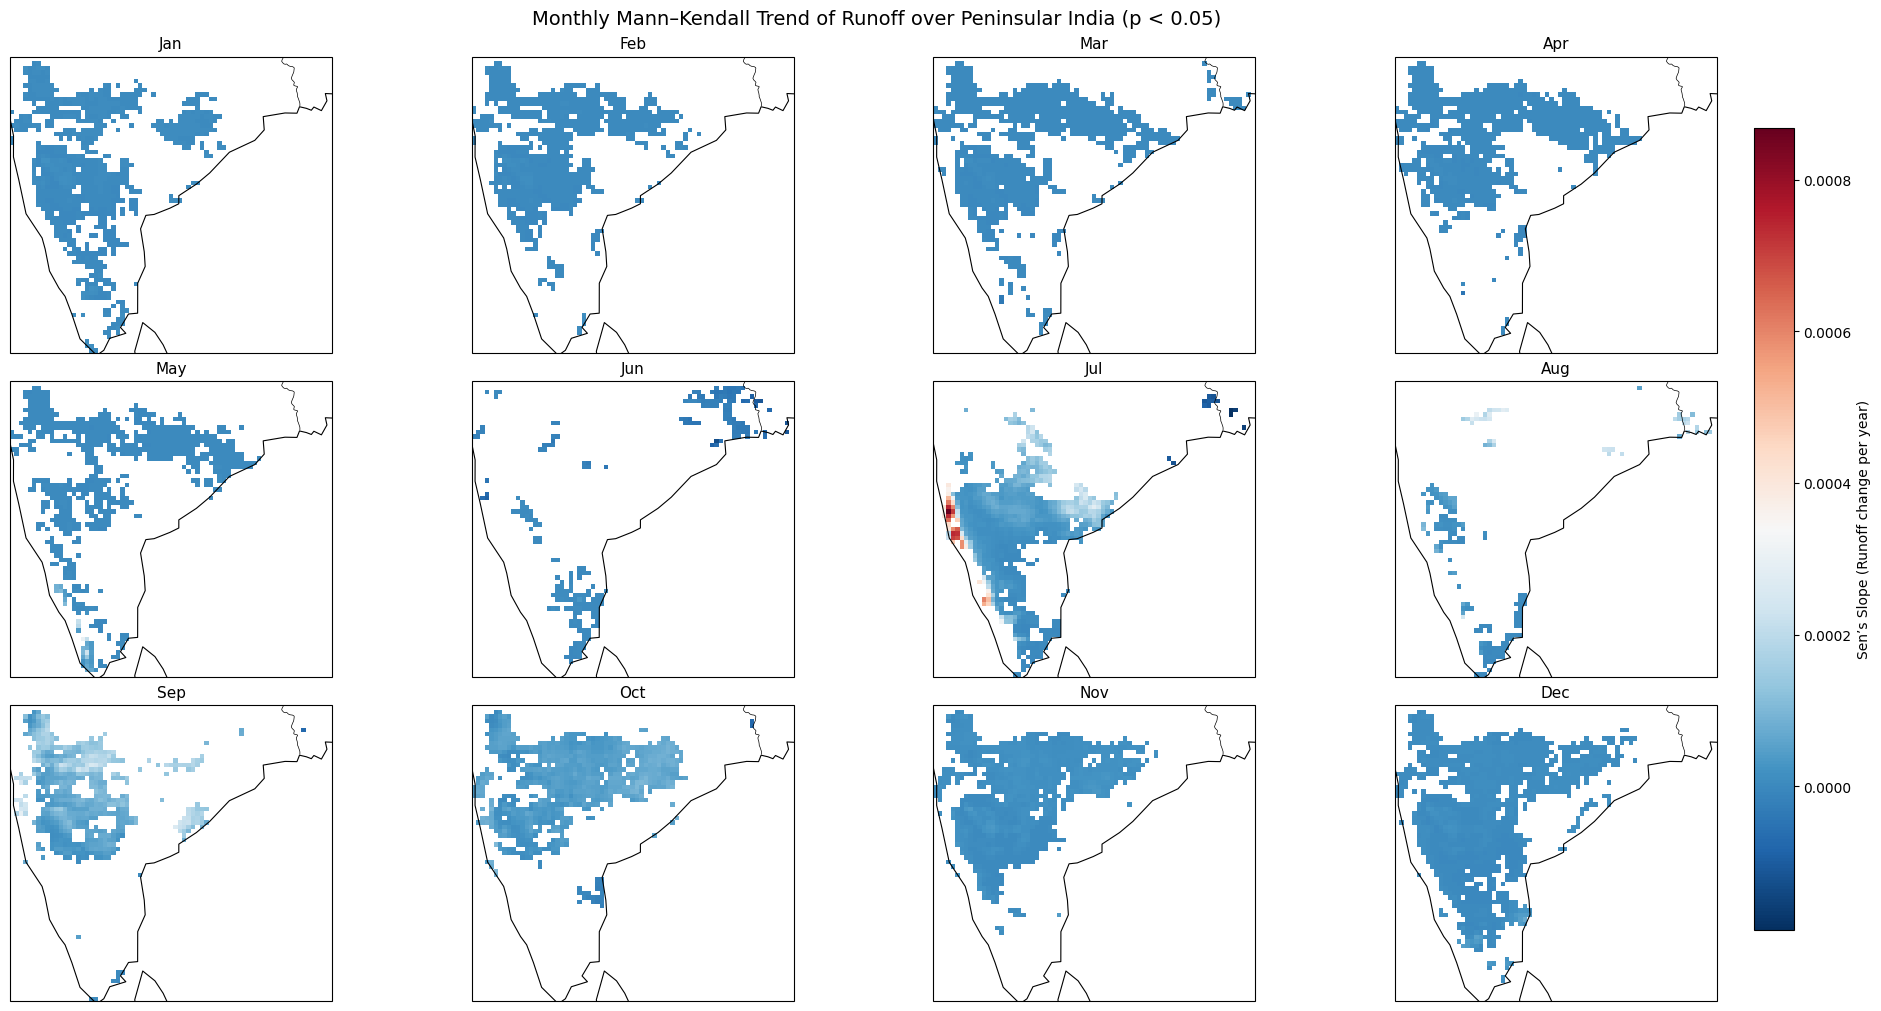

In [10]:
# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant runoff slopes only)
# ---------------------------------
all_runoff_slopes = []

for m in range(1, 13):
    runoff_slope = results[m]["sens_slope"]
    significant_slope = runoff_slope.where(results[m]["p_value"] < 0.05)
    all_runoff_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_runoff_slopes])
vmax = np.nanmax([s.max().values for s in all_runoff_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    runoff_mk = results[month]

    significant_slope = runoff_mk["sens_slope"].where(
        runoff_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",   # reversed for intuitive blue=decrease, red=increase
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Runoff change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Runoff over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()

Time Series Graph of Mean

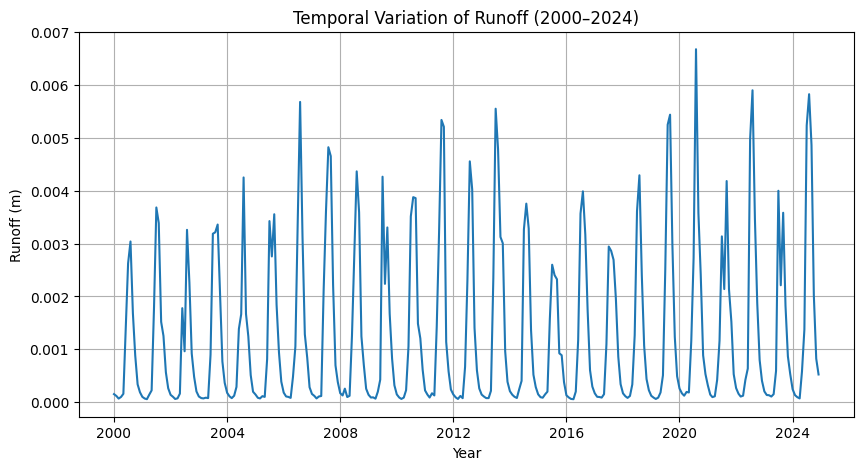

In [11]:
ro_ts = ro.mean(dim=['latitude','longitude'])
plt.figure(figsize=(10,5))

ro_ts.plot(label='Run Off')

plt.title("Temporal Variation of Runoff (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Runoff (m)")
plt.grid(True)

plt.show()

Grouping of Mean by month

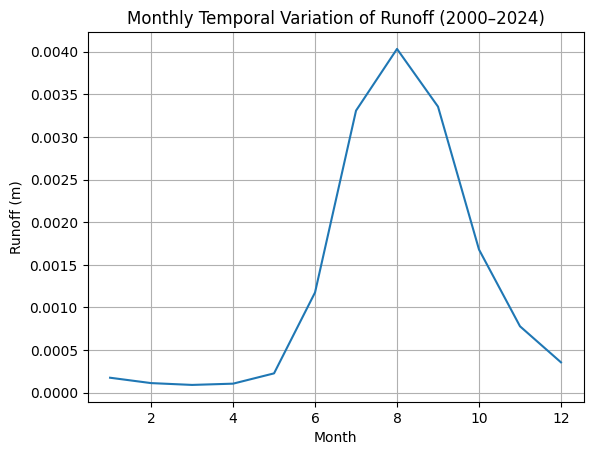

In [12]:
ro_season = ro_ts.groupby('valid_time.month').mean()
ro_season.plot(label='Runoff')
plt.title("Monthly Temporal Variation of Runoff (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Runoff (m)")
plt.grid(True)

Trend Analysis

In [13]:
time_ro = np.arange(len(ro_ts))

slope, intercept, r, p, std = linregress(time_ro, ro_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 1.8068062192393296e-06
p-value: 0.07680066646393523


Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [14]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Runoff from 2000 to 2024')

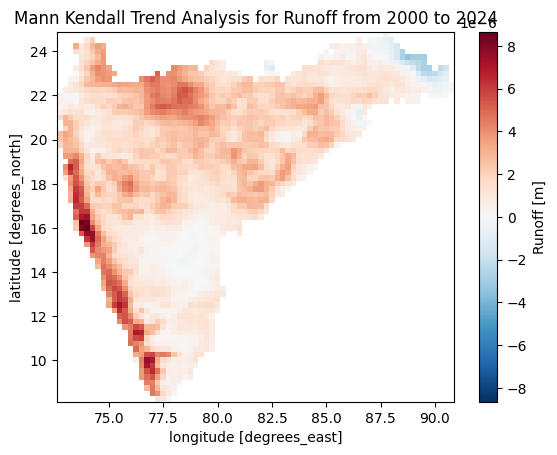

In [16]:
ro_trend = xr.apply_ufunc(
    trend_calc,
    ro,
    input_core_dims=[['valid_time']],
    vectorize=True
)

ro_trend.plot()
plt.title("Mann Kendall Trend Analysis for Runoff from 2000 to 2024")

Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for Runoff')

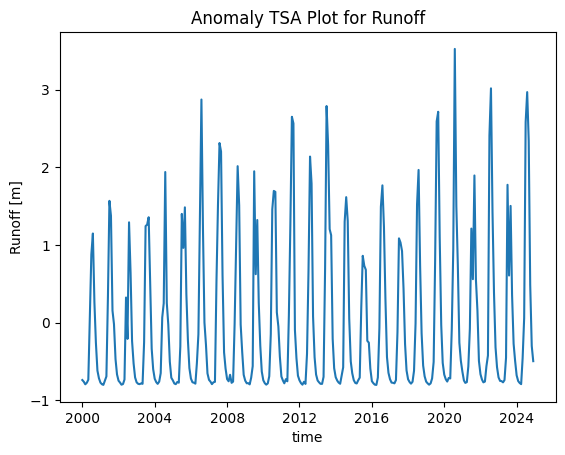

In [17]:
ro_mean = ro_ts.mean()
ro_std = ro_ts.std()
ro_std_anomaly = (ro_ts - ro_mean) / ro_std
ro_std_anomaly.plot()
plt.title("Anomaly TSA Plot for Runoff")